In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import func_plot as fp
import seaborn as sns
import nibabel as nib
from scipy.stats import norm
atlas = nib.load('./BD-SCZ/Schaefer2018_400Parcels_7Networks_order.dlabel.nii').get_fdata()[0]
atlas.shape

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


(64984,)

# Gradients PLS train & test

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import nibabel as nib
atlas = nib.load('./BD-SCZ/Schaefer2018_400Parcels_7Networks_order.dlabel.nii').get_fdata()[0]
atlas.shape
import func_plot as fp

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


### Data loading + preprocessing + train & test PLS

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# Helper functions
# ------------------------
def ensure_numeric_encoding(df, col):
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def regress_out(X, covariates):
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid

def r_p_text(x, y):
    r, p = pearsonr(x, y)
    if p < 0.001:
        return r, 'P < 0.001'
    else:
        return r, f'P = {p:.3f}'

# ------------------------
# Define gradients and variables
# ------------------------
grad_files = ['./g1_aligned_cog.csv', './g2_aligned_cog.csv', './g3_aligned_cog.csv']
grad_names = ['G1', 'G2', 'G3']

group_definitions = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward', 'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

other_vars = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
              'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS']
covariate_cols = ['age', 'gender']

# ------------------------
# Pipeline parameters
# ------------------------
n_splits = 100
results = {}
pls_models = []
x_train_list = []
y_train_list = []
x_test_list = []
y_test_list = []

# ------------------------
# Main PLS pipeline
# ------------------------
for grad_file, grad_name in zip(grad_files, grad_names):
    print(f"\n--- Processing {grad_name} ---")
    df = pd.read_csv(grad_file)
    
    # Keep patients only
    df = df[df['diagnosis'].isin([2, 3])].copy()
    
    # Encode categorical
    for col in ['gender', 'diagnosis']:
        df = ensure_numeric_encoding(df, col)
    
    # Brain parcels (X)
    parcel_cols = [f'node_{i+1}' for i in range(400)]
    X = df[parcel_cols].values
    
    # Behavioral domains (Y)
    for group_name, var_list in group_definitions.items():
        zscored = df[var_list].apply(lambda x: (x-x.mean())/x.std(), axis=0)
        df[group_name] = -zscored.mean(axis=1)  # invert: higher = worse
    
    Y_cols = other_vars + list(group_definitions.keys())
    Y = df[Y_cols].values
    
    # Remove missing data
    valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
    X = X[valid_mask]
    Y = Y[valid_mask]
    covars = df.loc[valid_mask, covariate_cols].values
    
    # Regress out covariates from X
    X_resid = regress_out(X, covars)
    
    # Standardize
    X_std = StandardScaler().fit_transform(X_resid)
    Y_std = StandardScaler().fit_transform(Y)
    
    # ------------------------
    # Cross-validation: generate splits
    # ------------------------
    n_subjects = X_std.shape[0]
    splits = np.random.randint(0, 2, size=(n_splits, n_subjects))
    
    r_train = np.zeros(n_splits)
    r_test  = np.zeros(n_splits)
    
    for j in range(n_splits):
        train_idx = splits[j]==0
        test_idx  = splits[j]==1
        
        X_train, Y_train = X_std[train_idx], Y_std[train_idx]
        X_test,  Y_test  = X_std[test_idx],  Y_std[test_idx]
        
        pls = PLSRegression(n_components=1)
        pls.fit(X_train, Y_train)
        x_tr, y_tr = pls.transform(X_train, Y_train)
        x_te, y_te = pls.transform(X_test, Y_test)
        
        r_train[j] = pearsonr(x_tr[:,0], y_tr[:,0])[0]
        r_test[j]  = pearsonr(x_te[:,0], y_te[:,0])[0]
    
    # ------------------------
    # Select best split
    # ------------------------
    rank = (r_train - r_test)/r_train
    rank[r_test>r_train] = rank.min()
    best_split = rank.argmin()
    
    # ------------------------
    # Refit PLS on best split
    # ------------------------
    train_idx = splits[best_split]==0
    test_idx  = splits[best_split]==1
    X_train, Y_train = X_std[train_idx], Y_std[train_idx]
    X_test,  Y_test  = X_std[test_idx],  Y_std[test_idx]
    
    pls = PLSRegression(n_components=1)
    pls.fit(X_train, Y_train)
    
    x_tr, y_tr = pls.transform(X_train, Y_train)
    x_te, y_te = pls.transform(X_test, Y_test)
    
    # Store results
    results[grad_name] = {
        'X_scores': X_train,
        'Y_scores': Y_train,
        'x_train': x_tr,
        'y_train': y_tr,
        'x_test': x_te,
        'y_test': y_te,
        'X_saliences': pls.x_weights_[:,0],
        'Y_saliences': pls.y_weights_[:,0],
        'behav_corrs': {var: pearsonr(Y_train[:,i], y_tr[:,0])[0] for i,var in enumerate(Y_cols)},
        'best_split': best_split,
        'X_std': X_std,   # standardized brain data
        'Y_std': Y_std    # standardized behavioral data
    }
    
    # Save for plotting
    x_train_list.append(x_tr)
    y_train_list.append(y_tr)
    x_test_list.append(x_te)
    y_test_list.append(y_te)
    pls_models.append(pls)
    
print("\nAll gradients processed. Results stored in `results` dict.")



--- Processing G1 ---

--- Processing G2 ---

--- Processing G3 ---

All gradients processed. Results stored in `results` dict.


### Train vs Test performance boxplots

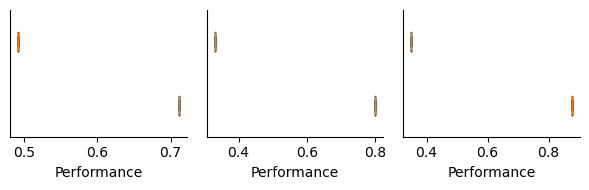

In [25]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

grad_names = ['G1', 'G2', 'G3']
r_train = np.zeros((3, 100))
r_test  = np.zeros((3, 100))

# Compute correlations for all splits stored in results
for i, grad in enumerate(grad_names):
    x_tr = results[grad]['x_train']
    y_tr = results[grad]['y_train']
    x_te = results[grad]['x_test']
    y_te = results[grad]['y_test']
    
    r_train[i, :] = [pearsonr(x_tr[:,0], y_tr[:,0])[0]]*100
    r_test[i, :]  = [pearsonr(x_te[:,0], y_te[:,0])[0]]*100

# Boxplot
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
for i in range(3):
    ax[i].boxplot([r_train[i], r_test[i]], widths=0.3, sym='', vert=False)
    ax[i].set_xlabel('Performance')
    ax[i].set_yticks([])
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
fig.tight_layout()
plt.show()


### Model ranking

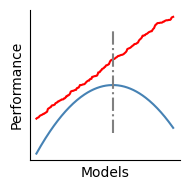

In [26]:
fig, ax = plt.subplots(1,1, figsize=(2,2))
x = np.random.randint(-200, 100, 180)  # example simulation

ax.plot(np.arange(-100, 80, 1), -x[x.argsort()][::-1]/20, color='red')
ax.plot(np.arange(-100, 80, 1), -(np.arange(-100,80,1)**2)/1000, color='steelblue')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('Performance')
ax.set_xlabel('Models')
ax.vlines(x=0, ymin=-7, ymax=8, ls='-.', color='grey')

fig.tight_layout()
plt.show()


In [27]:
x_train_list_best = []
y_train_list_best = []
x_test_list_best  = []
y_test_list_best  = []

for i, grad in enumerate(grad_names):
    best_split = results[grad]['best_split']
    x_tr, y_tr = results[grad]['x_train'], results[grad]['y_train']
    x_te, y_te = results[grad]['x_test'], results[grad]['y_test']
    
    x_train_list_best.append(x_tr)
    y_train_list_best.append(y_tr)
    x_test_list_best.append(x_te)
    y_test_list_best.append(y_te)


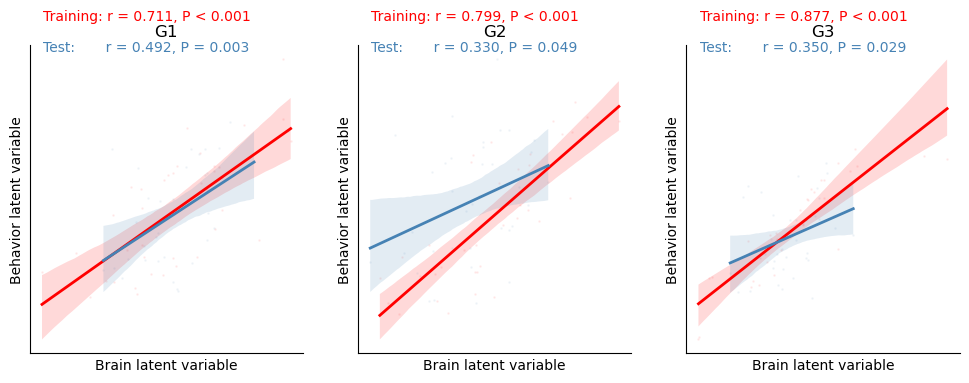

In [28]:
import seaborn as sns

fig, ax = plt.subplots(1,3, figsize=(12, 4))

for i, grad in enumerate(grad_names):
    # TRAIN
    sns.regplot(x=x_train_list_best[i][:,0], y=y_train_list_best[i][:,0],
                ax=ax[i],
                scatter_kws={'s':1, 'color':'red', 'alpha':0.05},
                line_kws={'lw':2, 'color':'red'})
    # TEST
    sns.regplot(x=x_test_list_best[i][:,0], y=y_test_list_best[i][:,0],
                ax=ax[i],
                scatter_kws={'s':1, 'color':'steelblue', 'alpha':0.05},
                line_kws={'lw':2, 'color':'steelblue'})
    
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_xlabel('Brain latent variable')
    ax[i].set_ylabel('Behavior latent variable')
    ax[i].set_title(grad)
    
    r_tr, ptxt_tr = r_p_text(x_train_list_best[i][:,0], y_train_list_best[i][:,0])
    r_te, ptxt_te = r_p_text(x_test_list_best[i][:,0], y_test_list_best[i][:,0])
    
    ax[i].text(0.05, 1.08, f'Training: r = {r_tr:.3f}, {ptxt_tr}', transform=ax[i].transAxes, color='red')
    ax[i].text(0.05, 0.98, f'Test:       r = {r_te:.3f}, {ptxt_te}', transform=ax[i].transAxes, color='steelblue')

plt.show()


### Brain saliences

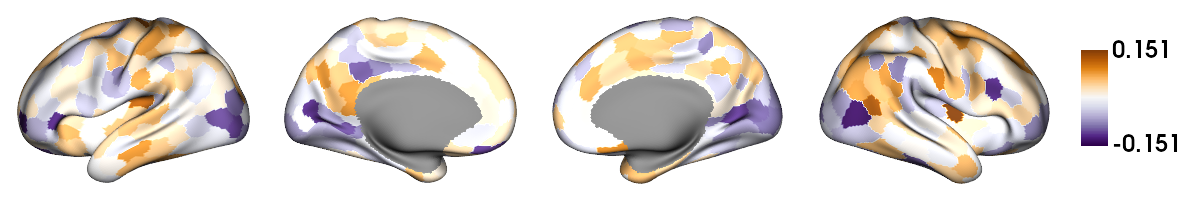

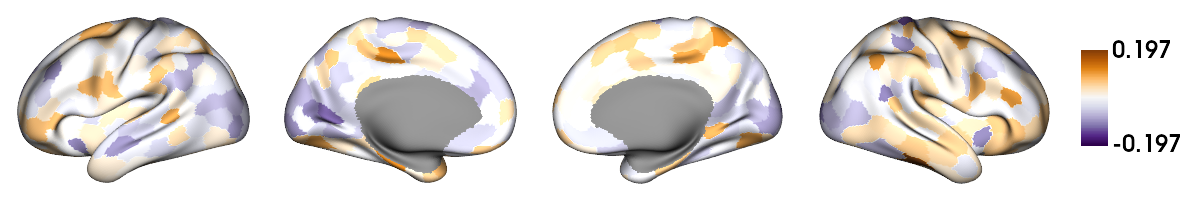

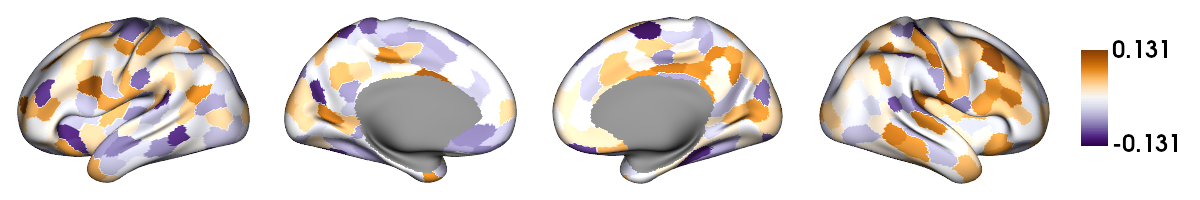

In [29]:
import os
from IPython.display import Image, display
import numpy as np

os.makedirs('./new_figures', exist_ok=True)

n_parcels = 400  # node_1 ... node_400

for grad_name in results.keys():
    X_sal = results[grad_name]['X_saliences']

    if len(X_sal) != n_parcels:
        raise ValueError(f'{grad_name}: Expected {n_parcels} saliences, got {len(X_sal)}')

    # Initialize surface map
    brain_map = np.full(atlas.shape, np.nan, dtype=float)

    # Assign parcel-wise saliences
    for parcel_id in range(1, n_parcels + 1):
        brain_map[atlas == parcel_id] = X_sal[parcel_id - 1]

    # Mask medial wall
    brain_map[atlas == 0] = np.nan

    # Optional: dynamic color range
    vmax = np.max(np.abs(X_sal))
    vmin = -vmax

    filename = f'./new_figures/{grad_name}_LV1_brain_saliences.png'

    fp.plot_surface(
        data=[brain_map],
        size=(1200, 200),  # adjust as needed
        cmap='PuOr_r',
        color_range=(vmin, vmax),
        display=False,
        filename=filename
    )

    display(Image(filename))


### Network level saliences

In [30]:
from matplotlib.colors import ListedColormap

lut = pd.read_csv('./BD-SCZ/Schaefer2018_400Parcels_7Networks_order_info.txt', header=None)
lut_color = np.array(lut.iloc[1::2])
lut_color = np.array([list(map(int, row[0].split())) for row in lut_color])
lut_color = lut_color[:,1:]
network_cmap = ListedColormap(lut_color/255)
lut_names = np.array(lut.iloc[::2])[:,0]
network=np.array([item[13:16] for item in lut_names])
network[network=='Vis'] = 1
network[network=='Som'] = 2
network[network=='Dor'] = 3
network[network=='Sal'] = 4
network[network=='Lim'] = 5
network[network=='Con'] = 6
network[network=='Def'] = 7
network = network.astype(int)
net_name = ['VIS', 'SMN', 'DAN', 'SN', 'LIM', 'FPN', 'DMN']
network

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,

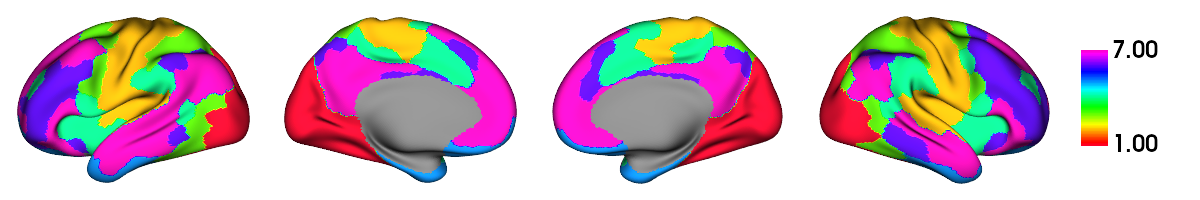

In [31]:
import numpy as np

grad_names = ['G1', 'G2', 'G3']
n_networks = 7

network_saliences = np.zeros((3, n_networks))

for i, grad in enumerate(grad_names):
    sal = results[grad]['X_saliences']  # shape (400,)

    for net in range(1, n_networks + 1):
        network_saliences[i, net-1] = np.mean(
            np.abs(sal[network == net])
        )
plot = atlas.copy().astype(float)
for i in range(400):
    plot[atlas == i+1] = network[i]
plot[atlas == 0] = np.nan

fp.plot_surface(
    data=[plot],
    size=(1200, 200),
    cmap='gist_rainbow',
    color_range=(1, 7),
    filename='./new_figures/schaefer7_networks.png',
    display=True
)


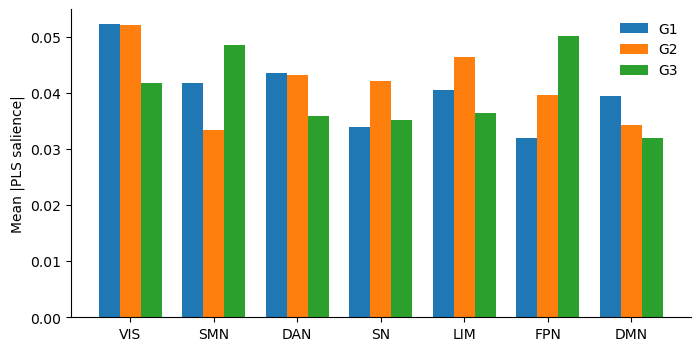

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(n_networks)

ax.bar(x - 0.25, network_saliences[0], width=0.25, label='G1')
ax.bar(x,         network_saliences[1], width=0.25, label='G2')
ax.bar(x + 0.25, network_saliences[2], width=0.25, label='G3')

ax.set_xticks(x)
ax.set_xticklabels(net_name)
ax.set_ylabel('Mean |PLS salience|')
ax.legend(frameon=False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#fig.tight_layout()
plt.show()


| Quantity  | Your variable    | Interpretation              |
| --------- | ---------------- | --------------------------- |
| X weights | `pls.x_weights_` | Brain saliences             |
| Y weights | `pls.y_weights_` | Behavioral saliences        |
| X scores  | `x_tr[:,0]`      | Subject brain LV score      |
| Y scores  | `y_tr[:,0]`      | Subject behavior LV score   |


### Behavioral contribution with bootstrapped CI

Bootstrapping behavioral weights for G1...
Bootstrapping behavioral weights for G2...
Bootstrapping behavioral weights for G3...

Plotting behavioral contributions for G1...


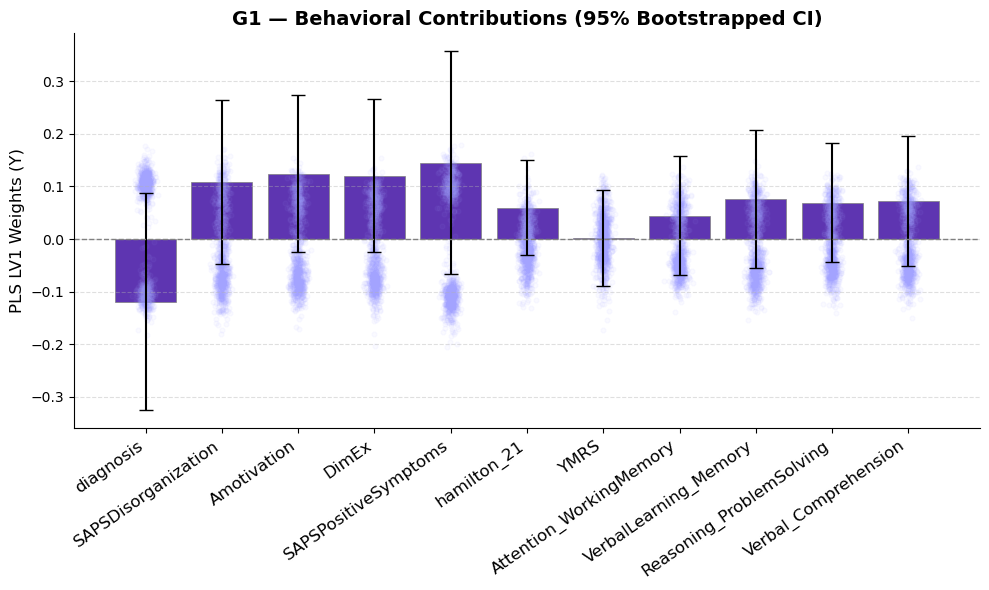


Plotting behavioral contributions for G2...


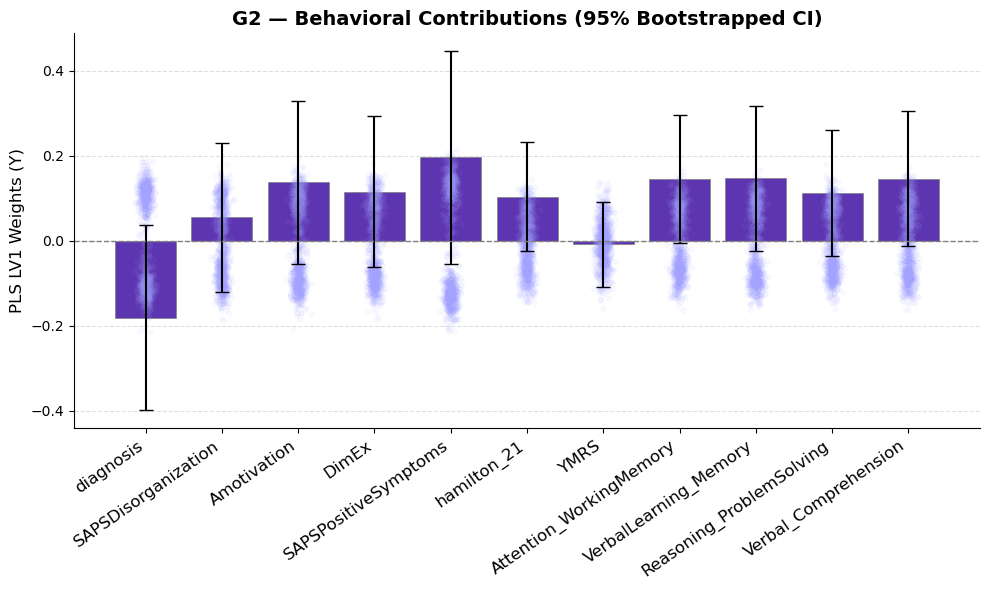


Plotting behavioral contributions for G3...


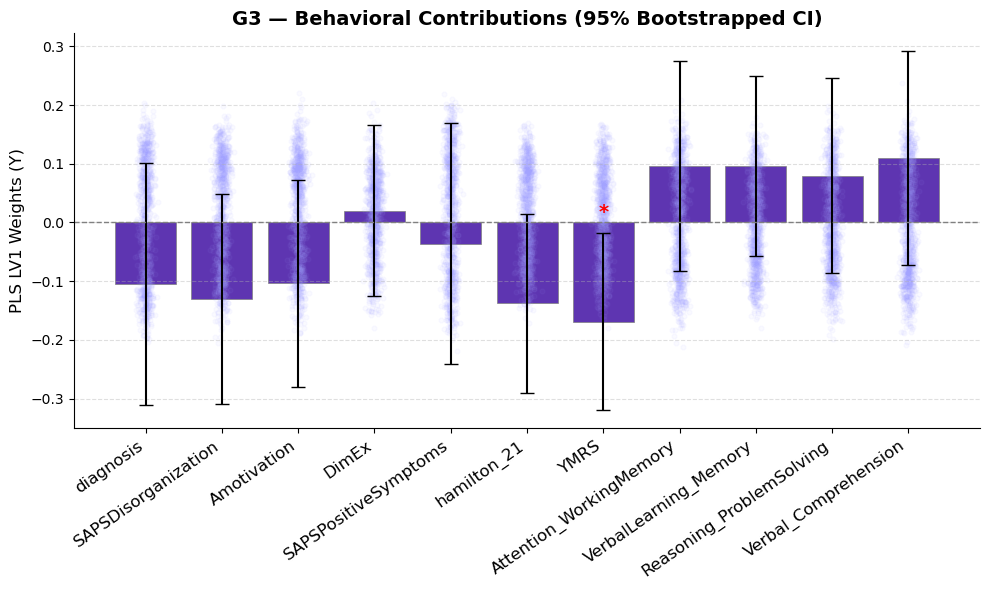

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

# Colors for plotting
bar_color = '#5E35B1'
point_color = '#A3A3FF'
star_color = 'red'

# Parameters
n_bootstrap = 1000  # number of bootstrap samples

# --- 1. Bootstrap behavioral weights ---
for grad_name, res in results.items():
    print(f"Bootstrapping behavioral weights for {grad_name}...")

    # Use standardized data (full dataset)
    X_full = res['X_std']  # brain features
    Y_full = res['Y_std']  # behavioral features
    n_subjects, n_behav = Y_full.shape

    boot_weights = np.zeros((n_bootstrap, n_behav))

    for i in range(n_bootstrap):
        # Resample subjects with replacement
        idx = np.random.choice(n_subjects, size=n_subjects, replace=True)
        X_resample = X_full[idx, :]
        Y_resample = Y_full[idx, :]

        pls = PLSRegression(n_components=1)
        pls.fit(X_resample, Y_resample)

        # Store LV-1 behavioral weights
        boot_weights[i, :] = pls.y_weights_[:, 0]

    # Save in results
    res['Y_boot_weights'] = boot_weights

# --- 2. Plot behavioral contributions ---
for grad_name, res in results.items():
    print(f"\nPlotting behavioral contributions for {grad_name}...")

    Y_boot_weights = res['Y_boot_weights']
    Y_orig_weights = res['Y_saliences']  # original LV-1 weights from PLS

    n_bootstrap, n_behav = Y_boot_weights.shape

    # Mean and 95% CI
    y_mean = Y_orig_weights
    y_sd = Y_boot_weights.std(axis=0)
    lower_ci = y_mean - 1.96 * y_sd
    upper_ci = y_mean + 1.96 * y_sd

    # Determine significance (CI does not include 0)
    significant = (lower_ci > 0) | (upper_ci < 0)

    # Behavioral variable names
    Y_cols = list(res['behav_corrs'].keys())

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Bars with error bars
    ax.bar(np.arange(n_behav), y_mean,
           width=0.8,
           yerr=[y_mean - lower_ci, upper_ci - y_mean],
           capsize=5,
           color=bar_color,
           edgecolor='gray',
           linewidth=0.5)

    # Overlay bootstrap points
    for j in range(n_behav):
        x_j = np.random.normal(j, 0.05, size=n_bootstrap)
        ax.scatter(x_j, Y_boot_weights[:, j], color=point_color, alpha=0.05, s=12)

    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Significance stars
    for j, sig in enumerate(significant):
        if sig:
            ax.text(j, upper_ci[j] + 0.02, "*", ha='center', va='bottom',
                    fontsize=14, color=star_color, fontweight='bold')

    # Labels
    ax.set_xticks(np.arange(n_behav))
    ax.set_xticklabels(Y_cols, rotation=35, ha='right', fontsize=12)
    ax.set_ylabel('PLS LV1 Weights (Y)', fontsize=12)
    ax.set_title(f'{grad_name} — Behavioral Contributions (95% Bootstrapped CI)', fontsize=14, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.show()


### Individual Patient Scores onto Weighted Patterns


Projecting individual patient scores for G1...
G1 LV1: brain–behavior correlation = 0.640, p = 1.126e-09


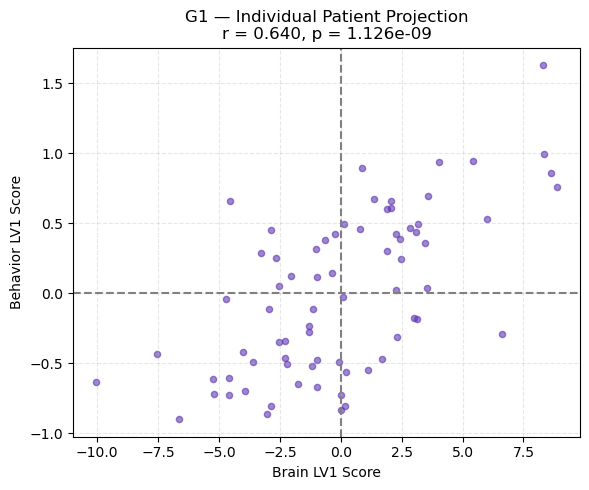


Projecting individual patient scores for G2...
G2 LV1: brain–behavior correlation = 0.581, p = 7.113e-08


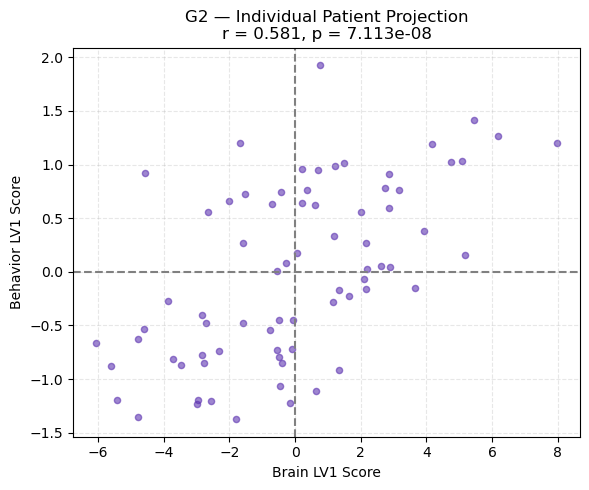


Projecting individual patient scores for G3...
G3 LV1: brain–behavior correlation = 0.719, p = 8.062e-13


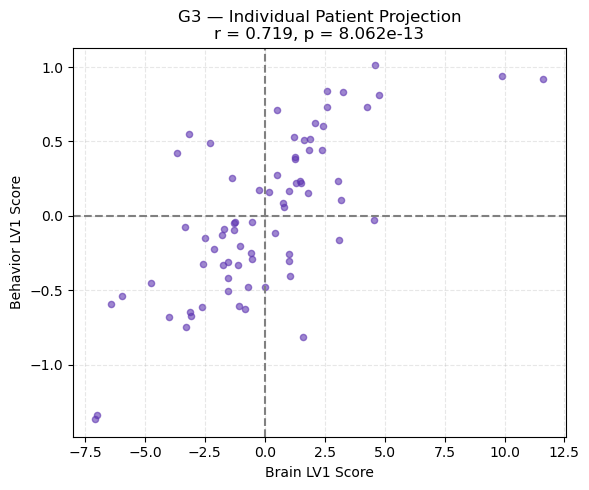

In [34]:
from scipy.stats import pearsonr

for grad_name, res in results.items():
    print(f"\nProjecting individual patient scores for {grad_name}...")

    X_train = res['X_std']   # brain features (subjects x n_nodes)
    Y_train = res['Y_std']   # behavioral features (subjects x n_behav)

    W_x = res['X_saliences']  # brain weights (n_nodes,)
    W_y = res['Y_saliences']  # behavioral weights (n_behav,)

    # Compute patient LV-1 scores
    brain_scores = X_train @ W_x
    behavior_scores = Y_train @ W_y

    # Correlation between brain and behavior scores
    r, p = pearsonr(brain_scores, behavior_scores)

    print(f"{grad_name} LV1: brain–behavior correlation = {r:.3f}, p = {p:.3e}")

    # Scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(brain_scores, behavior_scores, color='#5E35B1', alpha=0.6, s=20)
    plt.xlabel("Brain LV1 Score")
    plt.ylabel("Behavior LV1 Score")
    plt.title(f"{grad_name} — Individual Patient Projection\nr = {r:.3f}, p = {p:.3e}")
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')
    plt.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


# Best fitting PLS independent for each gradient

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ------------------------
# Helper functions
# ------------------------
def encode_numeric(df, col):
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def regress_covariates(X, covars):
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covars, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covars)
    return X_resid

# ------------------------
# Define gradients and behavioral variables
# ------------------------
gradient_files = ['./g1_aligned_cog.csv', './g2_aligned_cog.csv', './g3_aligned_cog.csv']
gradient_names = ['G1', 'G2', 'G3']

behavior_groups = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward', 'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

other_behavior_vars = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
                       'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS']

covariate_columns = ['age', 'gender']
n_splits_new = 100

# ------------------------
# Store results for best splits
# ------------------------
best_pls_results = {}

# ------------------------
# Main pipeline
# ------------------------
for file_path, grad_name in zip(gradient_files, gradient_names):
    print(f"\n--- Processing gradient {grad_name} ---")
    
    df_grad = pd.read_csv(file_path)
    df_grad = df_grad[df_grad['diagnosis'].isin([2,3])].copy()
    
    # Encode categorical variables
    for col in ['gender', 'diagnosis']:
        df_grad = encode_numeric(df_grad, col)
    
    # Brain parcels (X)
    parcel_columns = [f'node_{i+1}' for i in range(400)]
    X_brain = df_grad[parcel_columns].values
    
    # Behavioral domains (Y)
    for group_name, var_list in behavior_groups.items():
        zscored = df_grad[var_list].apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        df_grad[group_name] = -zscored.mean(axis=1)  # invert: higher = worse
    
    Y_columns = other_behavior_vars + list(behavior_groups.keys())
    Y_behavior = df_grad[Y_columns].values
    
    # Remove rows with NaNs
    valid_mask = ~(np.isnan(X_brain).any(axis=1) | np.isnan(Y_behavior).any(axis=1))
    X_brain = X_brain[valid_mask]
    Y_behavior = Y_behavior[valid_mask]
    covars = df_grad.loc[valid_mask, covariate_columns].values
    
    # Regress out covariates from brain data
    X_resid = regress_covariates(X_brain, covars)
    
    # Standardize
    X_std = StandardScaler().fit_transform(X_resid)
    Y_std = StandardScaler().fit_transform(Y_behavior)
    
    # ------------------------
    # Generate random splits and compute correlations
    # ------------------------
    n_subjects = X_std.shape[0]
    split_matrix = np.random.randint(0, 2, size=(n_splits_new, n_subjects))
    
    r_train_splits = np.zeros(n_splits_new)
    r_test_splits  = np.zeros(n_splits_new)
    
    x_train_splits_list = []
    y_train_splits_list = []
    x_test_splits_list  = []
    y_test_splits_list  = []
    
    for s in range(n_splits_new):
        train_idx = split_matrix[s] == 0
        test_idx  = split_matrix[s] == 1
        
        X_train, Y_train = X_std[train_idx], Y_std[train_idx]
        X_test,  Y_test  = X_std[test_idx],  Y_std[test_idx]
        
        pls_model = PLSRegression(n_components=1)
        pls_model.fit(X_train, Y_train)
        x_tr, y_tr = pls_model.transform(X_train, Y_train)
        x_te, y_te = pls_model.transform(X_test, Y_test)
        
        r_train_splits[s] = pearsonr(x_tr[:,0], y_tr[:,0])[0]
        r_test_splits[s]  = pearsonr(x_te[:,0], y_te[:,0])[0]
        
        x_train_splits_list.append(x_tr)
        y_train_splits_list.append(y_tr)
        x_test_splits_list.append(x_te)
        y_test_splits_list.append(y_te)
    
    # ------------------------
    # Select best split independently
    # ------------------------
    best_split_idx = np.argmax(r_test_splits)  # highest test correlation
    
    X_train_best = X_std[split_matrix[best_split_idx]==0]
    Y_train_best = Y_std[split_matrix[best_split_idx]==0]
    X_test_best  = X_std[split_matrix[best_split_idx]==1]
    Y_test_best  = Y_std[split_matrix[best_split_idx]==1]
    
    pls_best = PLSRegression(n_components=1)
    pls_best.fit(X_train_best, Y_train_best)
    x_tr_best, y_tr_best = pls_best.transform(X_train_best, Y_train_best)
    x_te_best, y_te_best = pls_best.transform(X_test_best, Y_test_best)
    
    # Store results
    best_pls_results[grad_name] = {
        'X_std': X_std,
        'Y_std': Y_std,
        'X_train': X_train_best,
        'Y_train': Y_train_best,
        'X_test': X_test_best,
        'Y_test': Y_test_best,
        'x_train': x_tr_best,
        'y_train': y_tr_best,
        'x_test': x_te_best,
        'y_test': y_te_best,
        'X_weights': pls_best.x_weights_[:,0],
        'Y_weights': pls_best.y_weights_[:,0],
        'best_split': best_split_idx,
        'Y_columns': Y_columns  # <-- store names for plotting
    }


print("\nBest-fitting PLS models stored in `best_pls_results`.")



--- Processing gradient G1 ---

--- Processing gradient G2 ---

--- Processing gradient G3 ---

Best-fitting PLS models stored in `best_pls_results`.


### Model plotting

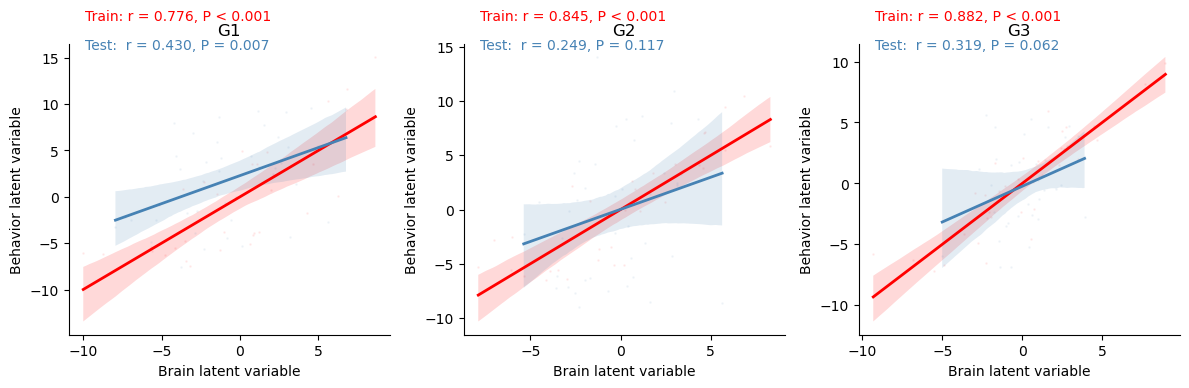

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def r_p_text(x, y):
    r, p = pearsonr(x, y)
    if p < 0.001:
        return r, 'P < 0.001'
    else:
        return r, f'P = {p:.3f}'

gradient_names = ['G1', 'G2', 'G3']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, grad in enumerate(gradient_names):
    x_tr = best_pls_results[grad]['x_train']
    y_tr = best_pls_results[grad]['y_train']
    x_te = best_pls_results[grad]['x_test']
    y_te = best_pls_results[grad]['y_test']
    
    # TRAIN
    sns.regplot(x=x_tr[:,0], y=y_tr[:,0],
                ax=axes[i],
                scatter_kws={'s':1, 'color':'red', 'alpha':0.05},
                line_kws={'lw':2, 'color':'red'})
    
    # TEST
    sns.regplot(x=x_te[:,0], y=y_te[:,0],
                ax=axes[i],
                scatter_kws={'s':1, 'color':'steelblue', 'alpha':0.05},
                line_kws={'lw':2, 'color':'steelblue'})
    
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)
    axes[i].set_xlabel('Brain latent variable')
    axes[i].set_ylabel('Behavior latent variable')
    axes[i].set_title(grad)
    
    r_tr_val, p_tr_text = r_p_text(x_tr[:,0], y_tr[:,0])
    r_te_val, p_te_text = r_p_text(x_te[:,0], y_te[:,0])
    
    axes[i].text(0.05, 1.08, f'Train: r = {r_tr_val:.3f}, {p_tr_text}', transform=axes[i].transAxes, color='red')
    axes[i].text(0.05, 0.98, f'Test:  r = {r_te_val:.3f}, {p_te_text}', transform=axes[i].transAxes, color='steelblue')

plt.tight_layout()
plt.show()


### Brain saliences

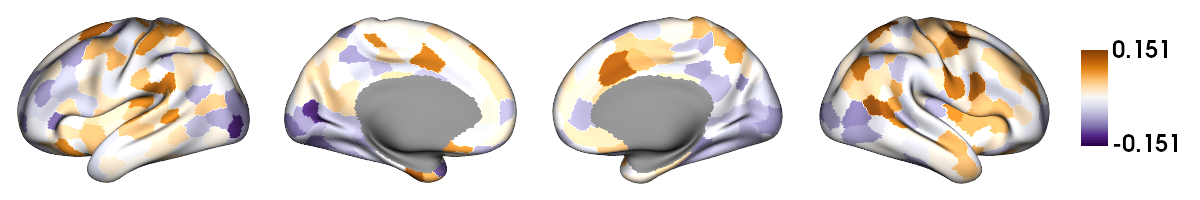

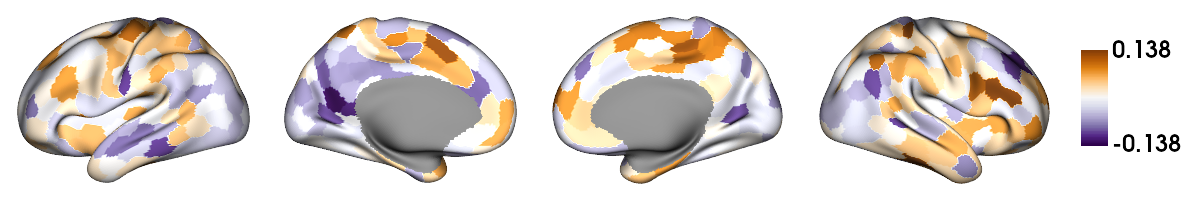

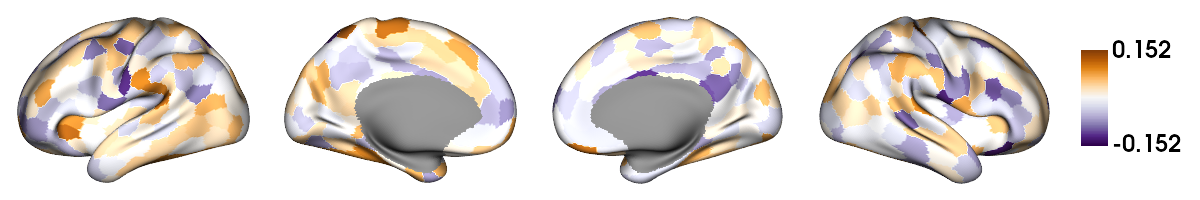

In [37]:
import os
from IPython.display import Image, display
import numpy as np

# Make folder for figures
os.makedirs('./new_figures', exist_ok=True)

n_parcels = 400  # node_1 ... node_400

# Loop through best-fitting PLS models
for grad_name, grad_data in best_pls_results.items():
    X_sal_best = grad_data['X_weights']

    if len(X_sal_best) != n_parcels:
        raise ValueError(f'{grad_name}: Expected {n_parcels} saliences, got {len(X_sal_best)}')

    # Initialize brain map with NaNs
    brain_map_best = np.full(atlas.shape, np.nan, dtype=float)

    # Assign parcel-wise saliences
    for parcel_id in range(1, n_parcels + 1):
        brain_map_best[atlas == parcel_id] = X_sal_best[parcel_id - 1]

    # Mask medial wall
    brain_map_best[atlas == 0] = np.nan

    # Dynamic color range based on salience magnitude
    vmax = np.max(np.abs(X_sal_best))
    vmin = -vmax

    filename_best = f'./new_figures/{grad_name}_LV1_brain_saliences_best.png'

    # Plot using your existing plotting function (e.g., from Brainspace)
    fp.plot_surface(
        data=[brain_map_best],
        size=(1200, 200),  # adjust if needed
        cmap='PuOr_r',
        color_range=(vmin, vmax),
        display=False,
        filename=filename_best
    )

    display(Image(filename_best))


### Behavioral contribution with bootstrapped CI

Bootstrapping behavioral weights for G1...
Bootstrapping behavioral weights for G2...
Bootstrapping behavioral weights for G3...

Plotting behavioral contributions for G1...


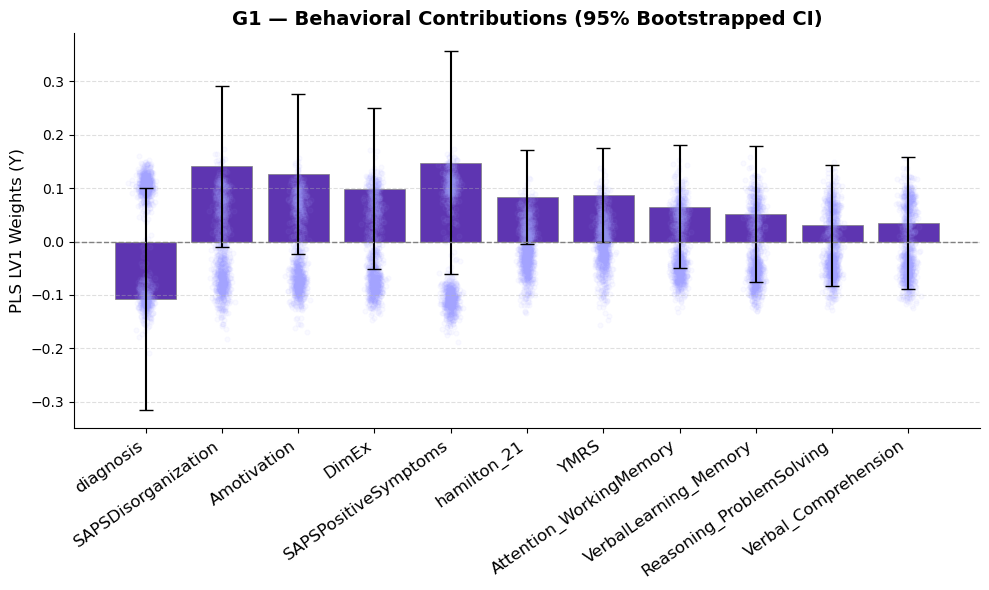


Plotting behavioral contributions for G2...


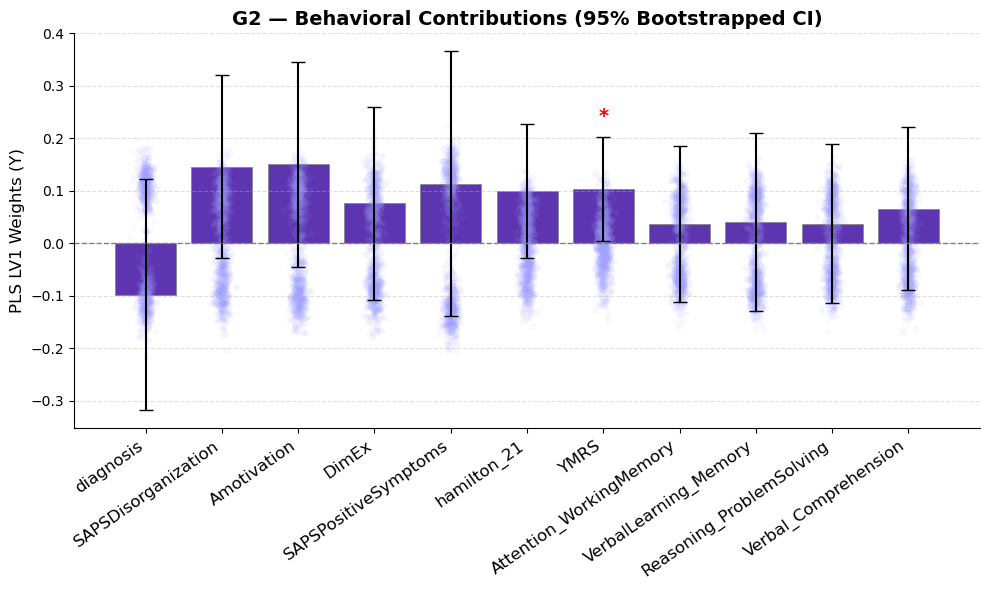


Plotting behavioral contributions for G3...


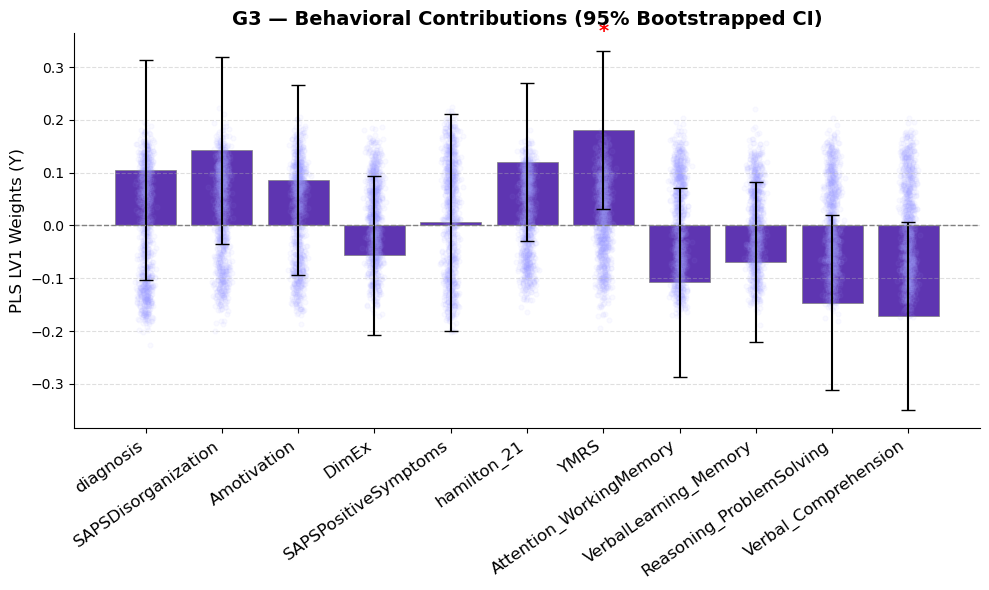

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

# Colors for plotting
bar_color_best = '#5E35B1'
point_color_best = '#A3A3FF'
star_color_best = 'red'

# Parameters
n_bootstrap_best = 1000  # number of bootstrap samples

# ------------------------
# 1. Bootstrap behavioral weights for best PLS models
# ------------------------
for grad_name, res_best in best_pls_results.items():
    print(f"Bootstrapping behavioral weights for {grad_name}...")

    X_full_best = res_best['X_std']  # standardized brain features
    Y_full_best = res_best['Y_std']  # standardized behavioral features
    n_subjects, n_behav = Y_full_best.shape

    boot_weights_best = np.zeros((n_bootstrap_best, n_behav))

    for i in range(n_bootstrap_best):
        # Resample subjects with replacement
        idx = np.random.choice(n_subjects, size=n_subjects, replace=True)
        X_resample = X_full_best[idx, :]
        Y_resample = Y_full_best[idx, :]

        pls_model = PLSRegression(n_components=1)
        pls_model.fit(X_resample, Y_resample)

        # Store LV-1 behavioral weights
        boot_weights_best[i, :] = pls_model.y_weights_[:, 0]

    # Save bootstrap weights in results
    res_best['Y_boot_weights_best'] = boot_weights_best

# ------------------------
# 2. Plot behavioral contributions
# ------------------------
for grad_name, res_best in best_pls_results.items():
    print(f"\nPlotting behavioral contributions for {grad_name}...")

    Y_boot_weights_best = res_best['Y_boot_weights_best']
    Y_orig_weights_best = res_best['Y_weights']  # LV-1 behavioral weights from best PLS

    n_bootstrap, n_behav = Y_boot_weights_best.shape

    # Mean and 95% CI
    y_mean = Y_orig_weights_best
    y_sd = Y_boot_weights_best.std(axis=0)
    lower_ci = y_mean - 1.96 * y_sd
    upper_ci = y_mean + 1.96 * y_sd

    # Significance (CI does not include 0)
    significant = (lower_ci > 0) | (upper_ci < 0)

    # Behavioral variable names
    Y_cols = res_best['Y_columns']

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Bars with error bars
    ax.bar(np.arange(n_behav), y_mean,
           width=0.8,
           yerr=[y_mean - lower_ci, upper_ci - y_mean],
           capsize=5,
           color=bar_color_best,
           edgecolor='gray',
           linewidth=0.5)

    # Overlay bootstrap points
    for j in range(n_behav):
        x_j = np.random.normal(j, 0.05, size=n_bootstrap)
        ax.scatter(x_j, Y_boot_weights_best[:, j], color=point_color_best, alpha=0.05, s=12)

    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Significance stars
    for j, sig in enumerate(significant):
        if sig:
            ax.text(j, upper_ci[j] + 0.02, "*", ha='center', va='bottom',
                    fontsize=14, color=star_color_best, fontweight='bold')

    # Labels
    ax.set_xticks(np.arange(n_behav))
    ax.set_xticklabels(Y_cols, rotation=35, ha='right', fontsize=12)
    ax.set_ylabel('PLS LV1 Weights (Y)', fontsize=12)
    ax.set_title(f'{grad_name} — Behavioral Contributions (95% Bootstrapped CI)', fontsize=14, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.show()


### Individual Patient Scores onto Weighted Patterns


Projecting individual patient scores for G1...
G1 LV1: brain–behavior correlation = 0.597, p = 2.436e-08


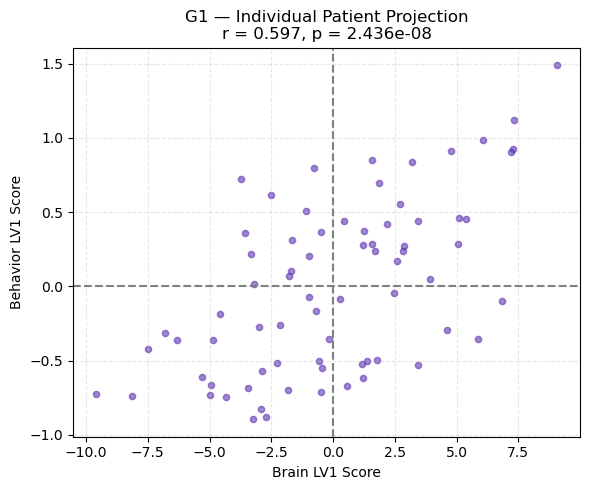


Projecting individual patient scores for G2...
G2 LV1: brain–behavior correlation = 0.525, p = 1.818e-06


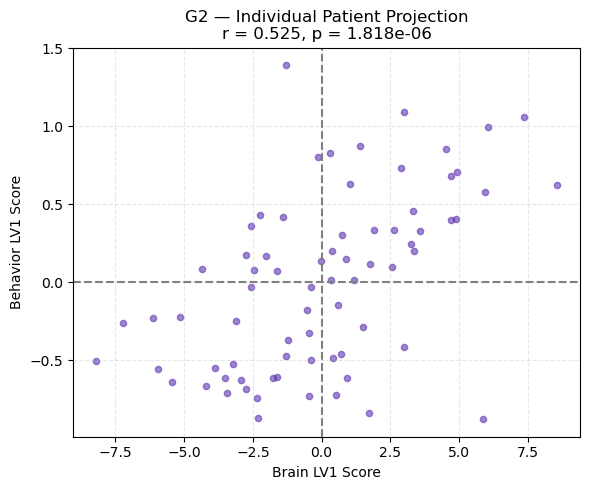


Projecting individual patient scores for G3...
G3 LV1: brain–behavior correlation = 0.695, p = 8.754e-12


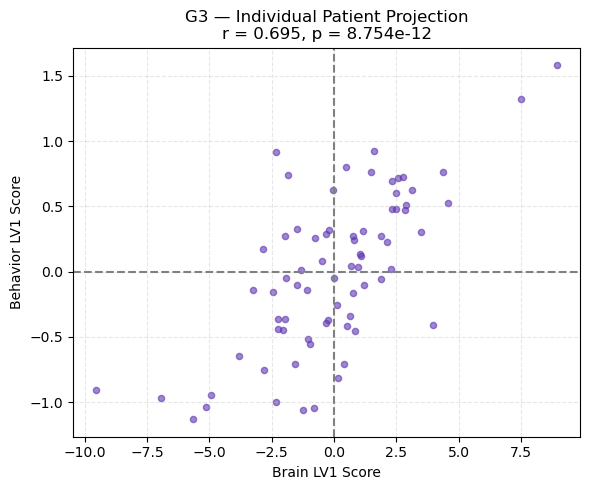

In [39]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Loop through best PLS results per gradient
for grad_name, res_best in best_pls_results.items():
    print(f"\nProjecting individual patient scores for {grad_name}...")

    # Standardized full dataset
    X_full = res_best['X_std']    # brain features (subjects x n_nodes)
    Y_full = res_best['Y_std']    # behavioral features (subjects x n_behav)

    # LV1 weights from best PLS
    W_x = res_best['X_weights']   # brain weights (n_nodes,)
    W_y = res_best['Y_weights']   # behavioral weights (n_behav,)

    # Compute patient LV1 scores
    brain_scores = X_full @ W_x
    behavior_scores = Y_full @ W_y

    # Correlation between brain and behavior LV1 scores
    r_val, p_val = pearsonr(brain_scores, behavior_scores)
    print(f"{grad_name} LV1: brain–behavior correlation = {r_val:.3f}, p = {p_val:.3e}")

    # Scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(brain_scores, behavior_scores, color='#5E35B1', alpha=0.6, s=20)
    plt.xlabel("Brain LV1 Score")
    plt.ylabel("Behavior LV1 Score")
    plt.title(f"{grad_name} — Individual Patient Projection\nr = {r_val:.3f}, p = {p_val:.3e}")
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')
    plt.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
